# Telco Customer Churn

**Problem:** Telecom companies lose customers every month. This project builds a churn prediction system, prioritizes high-risk users, and segments churners into distinct behavioral groups.

---

# 1 — Exploratory Data Analysis (EDA)

In [704]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [705]:
# Load dataset
Telco_data=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [706]:
Telco_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [707]:
# Total Charges column is an object
Telco_data['TotalCharges']=pd.to_numeric(Telco_data['TotalCharges'],errors='coerce')

In [708]:
Telco_data.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [709]:
# SeniorCitizen is a categorical column
# Average monthly charges is 64.76 USD whereas 25% of population pay more than 89.85 USD
# 50% of people have tenure less than 29 months

In [710]:
Telco_data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [711]:
# Checking for null values
Telco_data.isna().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [712]:
# Since the missing rows are 11 (~0.15%), let's remove them
Telco_data=Telco_data.dropna()

In [713]:
# Checking for duplicate rows
Telco_data.duplicated().sum()

np.int64(0)

C:\Users\Puneeth\AppData\Local\Temp\ipykernel_37880\517491600.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=Telco_data['Churn'], palette='viridis', order=Telco_data['Churn'].value_counts().index)


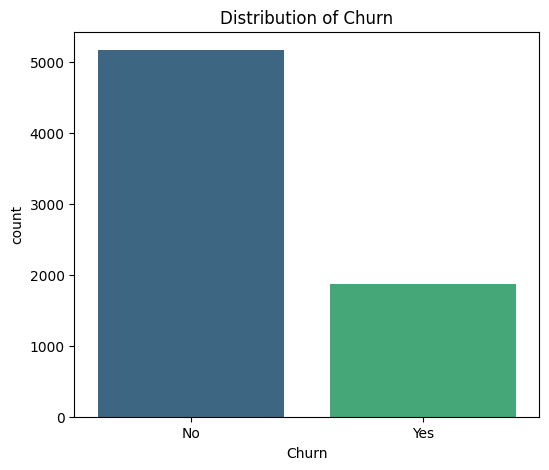

In [714]:
# Visualization of Distribution
plt.figure(figsize=(6,5))
sns.countplot(x=Telco_data['Churn'], palette='viridis', order=Telco_data['Churn'].value_counts().index)
plt.title('Distribution of Churn')
plt.show()

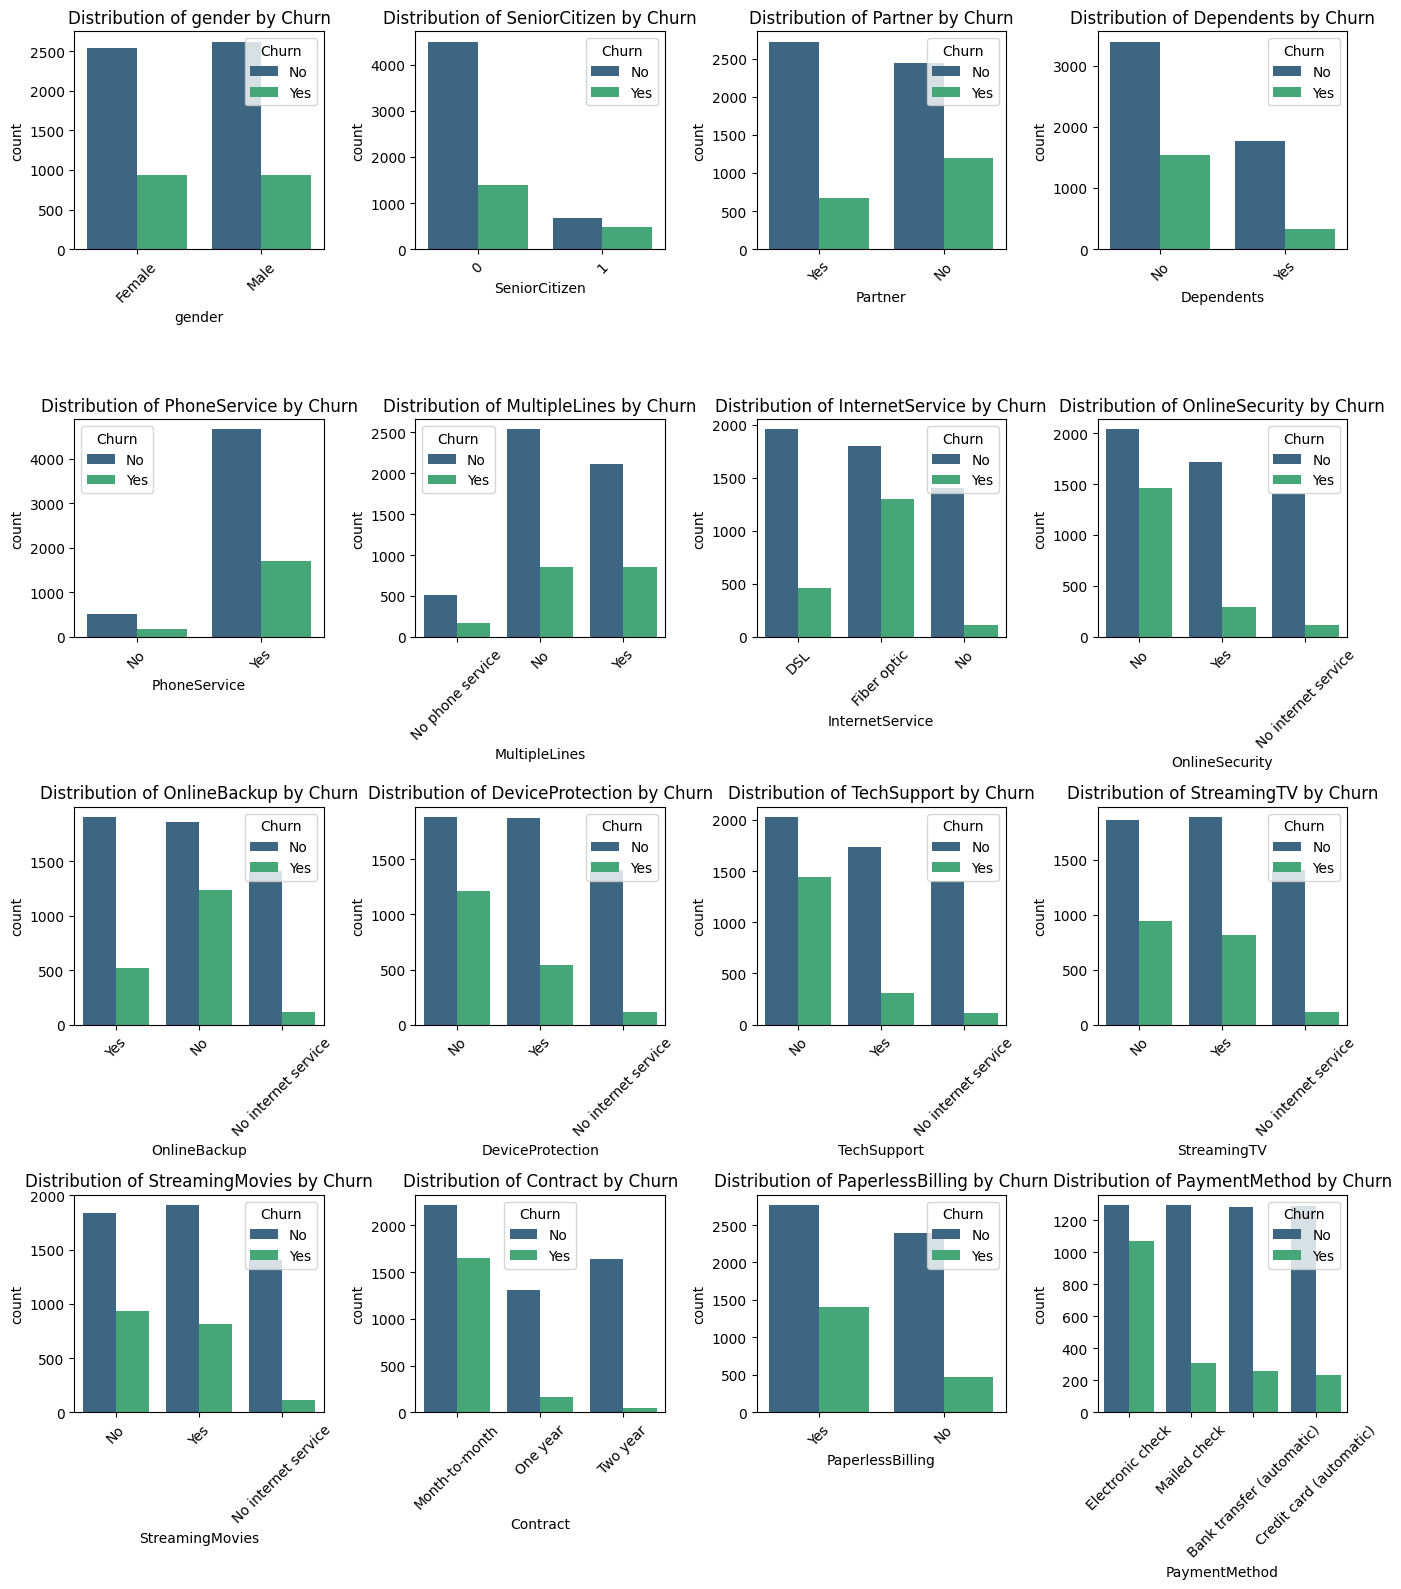

In [715]:
# With a hue of "CHURN"

# Visualizing other columns

cols=['gender', 'SeniorCitizen', 'Partner', 'Dependents',
        'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod']

plt.figure(figsize=(14,16))
for i,col in enumerate(cols):
    plt.subplot(4,4,i+1)
    sns.countplot(data=Telco_data, x=col, palette='viridis', hue='Churn')
    plt.title(f'Distribution of {col} by Churn')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [716]:
# INSIGHTS

# Customers with month-to-month contracts exhibit significantly higher churn compared to those on longer-term contracts
# Customers without online security,tech support, Online backup show noticeably higher churn meaning additional services may
#increase customer dependency on service provider.
# Automatic payment methods may indicate more stable customers, whereas electronic check users may represent more price sensitivity
# Customers with dependents show lower churn likely because of heavily relying on consistent services

# These show customers with additional services and long-term commitments tend to churn less

In [717]:
# Let's see churn rates across contracts
pd.crosstab(Telco_data['Contract'],Telco_data['Churn'],normalize='index')

Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887228,0.112772
Two year,0.971513,0.028487


In [718]:
# Contract type shows a strong relationship with customer behavior
# This indicates that longer contractual commitments substantially improve customer retention

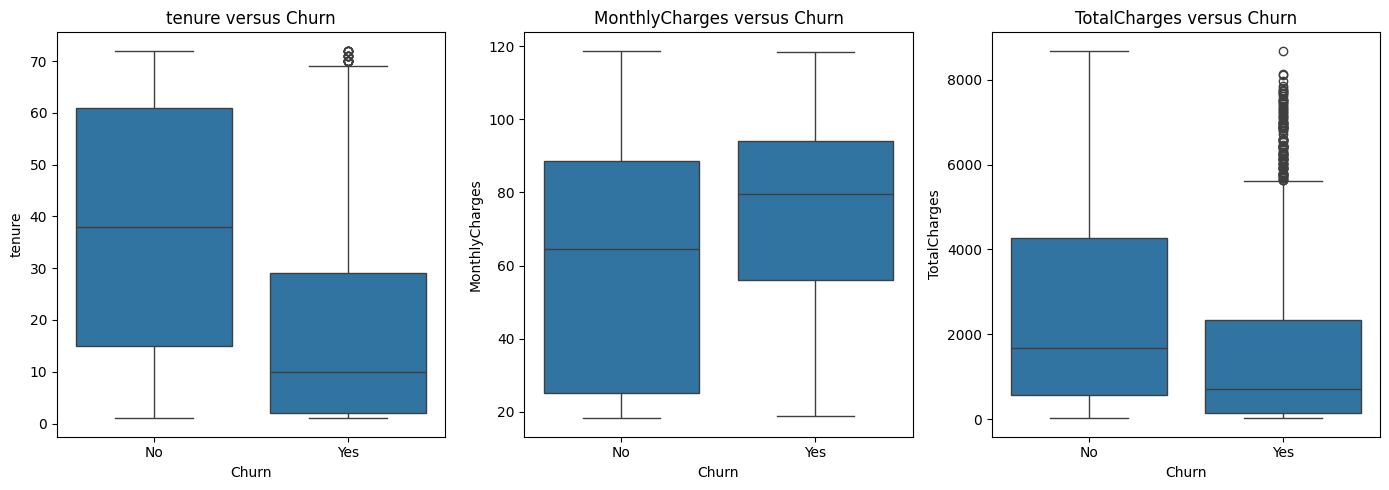

In [719]:
num_cols=['tenure','MonthlyCharges', 'TotalCharges']

plt.figure(figsize=(14,5))
for i,col in enumerate(num_cols):
    plt.subplot(1,3,i+1)
    sns.boxplot(x='Churn', y=col, data=Telco_data)
    plt.title(f'{col} versus Churn')
plt.tight_layout()
plt.show()

In [720]:
# INSIGHTS

# Customers who churn exhibit lower tenure, indicating churn is more common among relatively new customers
# And they also show lower Total Charges. Interestingly, they tend to have very slight higher median monthly charges
# Suggesting higher recurring costs may contribute to dissatisfaction

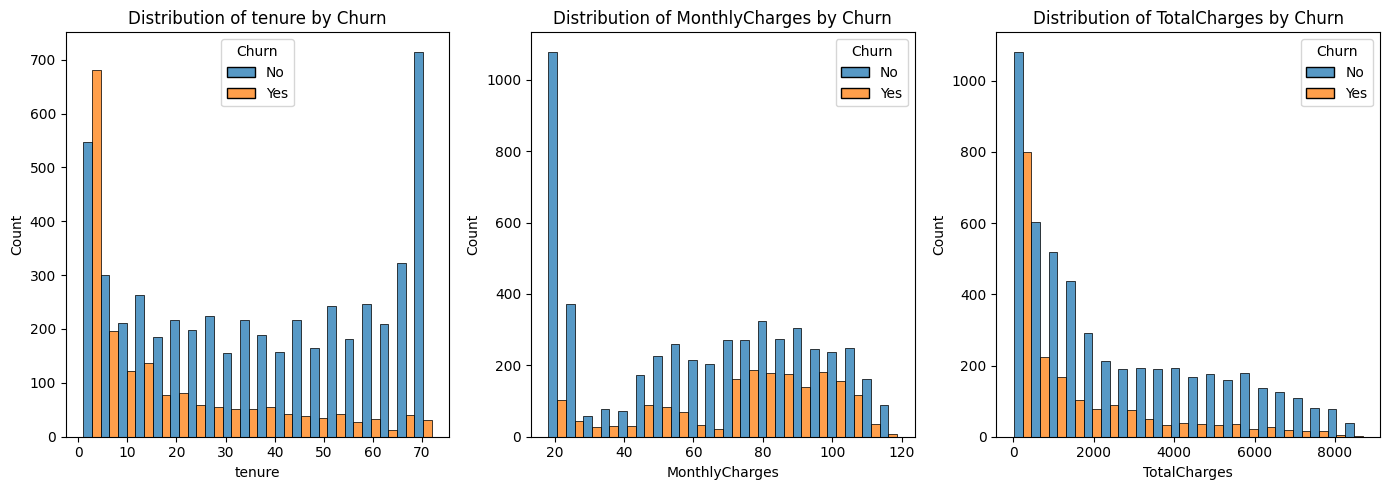

In [721]:
plt.figure(figsize=(14,5))
for i,col in enumerate(num_cols):
    plt.subplot(1,3,i+1)
    sns.histplot(hue='Churn', x=col, data=Telco_data, bins=20,multiple='dodge')
    plt.title(f'Distribution of {col} by Churn')
plt.tight_layout()
plt.show()

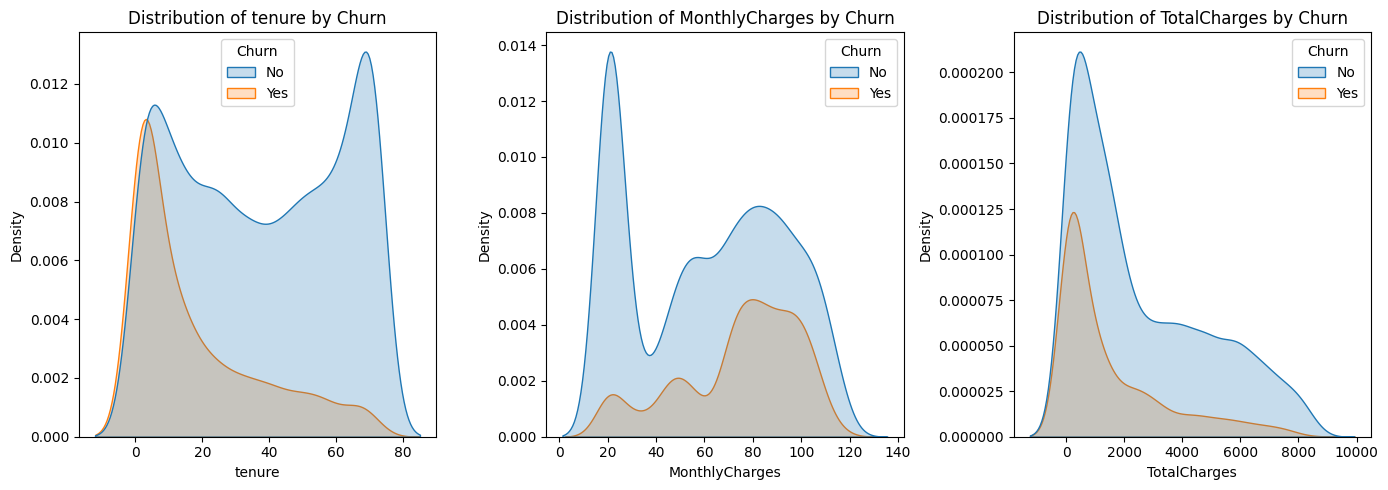

In [722]:
plt.figure(figsize=(14,5))
for i,col in enumerate(num_cols):
    plt.subplot(1,3,i+1)
    sns.kdeplot(hue='Churn', x=col, data=Telco_data, fill='True')
    plt.title(f'Distribution of {col} by Churn')
plt.tight_layout()
plt.show()

In [723]:
# The plots show that customers who do not churn dominate higher tenure and total charge ranges, reflecting longer engagement
# Churned customers are concentrated in lower tenure ranges, indicating many customers discontinue the service relatively early.

In [724]:
# Since there is a clear dominance in tenure, let's try segmenting it

Telco_data['TenureGroup']=pd.cut(Telco_data['tenure'],bins=[0,12,24,48,60,72],labels=['0-12','12-24','24-48','48-60','60-72'])

Text(0.5, 1.0, 'Churn Distribution across Tenure Groups')

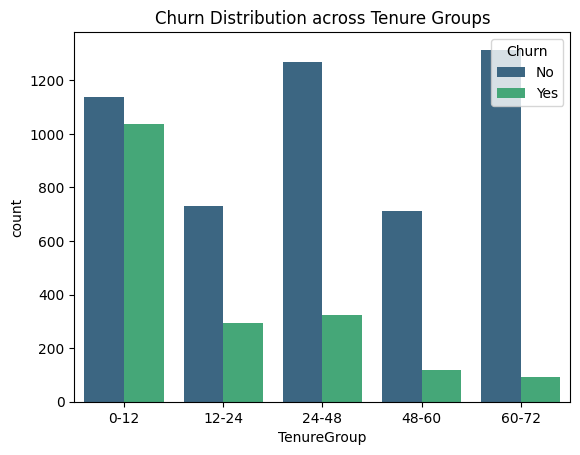

In [725]:
sns.countplot(data=Telco_data, x='TenureGroup', palette='viridis', hue='Churn')
plt.title('Churn Distribution across Tenure Groups')

In [726]:
# Calculating churn rate for better understanding
pd.crosstab(Telco_data['TenureGroup'],Telco_data['Churn'],normalize='index')

Churn,No,Yes
TenureGroup,,
0-12,0.523218,0.476782
12-24,0.712891,0.287109
24-48,0.796110,0.203890
48-60,0.855769,0.144231
60-72,0.933902,0.066098


In [727]:
# Tenure segmentation reveals a strong negative relationship between tenure and churn
# Customers within the first 12 months exhibit the highest churn rate, approximately half of the new customers discontinue early
# As tenure increases, churn rate declines steadily, reaching only 6% among customers with more than 60 months of tenure
# This suggests customer loyalty strengthens over time, and early stage is crucial for retention strategies

Text(0.5, 1.0, 'Correlation Heatmap for Numerical Features')

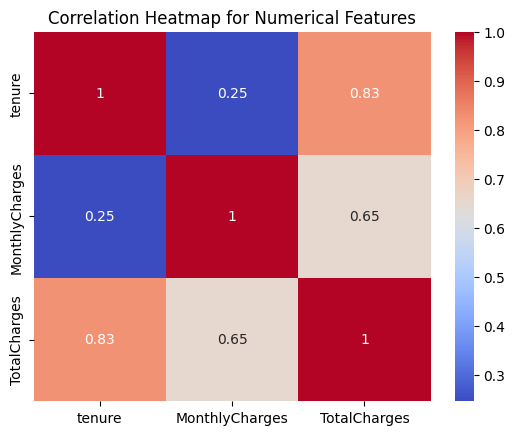

In [728]:
# Let's check correlation across numerical features
sns.heatmap(Telco_data[num_cols].corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap for Numerical Features")

In [729]:
# The heatmap reveals a strong positive relationship between tenure and total charges, which is expected since total charge
# accumulate over time. Monthly charge also shows a moderate correlation with total charges, indicating higher monthly billing
# contributes to overall spending. However, tenure and monthly charges exhibit a weak relationship, suggesting duration of a 
# customer's relationship with service is largely independent of monthly billing amount.

In [730]:
# Encoding categorical features
df_encoded=Telco_data.drop('customerID',axis=1) #customerID is just an identifier
df_encoded['Churn']=df_encoded['Churn'].map({'Yes':1,'No':0})
df_encoded=pd.get_dummies(df_encoded,drop_first=True)


df_encoded.to_csv('Telco_churn.csv')

# 2 — Modeling & Risk Segmentation

In [732]:
import pandas as pd

In [733]:
cluster_features=churn_df[[
    'tenure', 'MonthlyCharges','TotalCharges', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_No internet service',
       'OnlineSecurity_Yes', 'OnlineBackup_No internet service',
       'OnlineBackup_Yes', 'DeviceProtection_No internet service',
       'DeviceProtection_Yes', 'TechSupport_No internet service',
       'TechSupport_Yes',  'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
]]

In [734]:
df=pd.read_csv("Telco_churn.csv")

In [735]:
df.head()

,Unnamed: 0,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup_12-24,TenureGroup_24-48,TenureGroup_48-60,TenureGroup_60-72
0,0,0,1,29.85,29.85,0,False,True,False,False,...,False,False,True,False,True,False,False,False,False,False
1,1,0,34,56.95,1889.50,0,True,False,False,True,...,True,False,False,False,False,True,False,True,False,False
2,2,0,2,53.85,108.15,1,True,False,False,True,...,False,False,True,False,False,True,False,False,False,False
3,3,0,45,42.30,1840.75,0,True,False,False,False,...,True,False,False,False,False,False,False,True,False,False
4,4,0,2,70.70,151.65,1,False,False,False,True,...,False,False,True,False,True,False,False,False,False,False


In [736]:
df=df.drop("Unnamed: 0",axis=1)

In [737]:
X=df.drop("Churn",axis=1)  # Feature variables

In [738]:
X

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup_12-24,TenureGroup_24-48,TenureGroup_48-60,TenureGroup_60-72
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,True,False,True,False,False,False,False,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,True,False,False,False,False,True,False,True,False,False
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,True,False,False,True,False,False,False,False
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,True,False,False,False,False,False,False,True,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,True,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,0,24,84.80,1990.50,True,True,True,True,False,True,...,True,False,True,False,False,True,True,False,False,False
7028,0,72,103.20,7362.90,False,True,True,True,False,True,...,True,False,True,True,False,False,False,False,False,True
7029,0,11,29.60,346.45,False,True,True,False,True,False,...,False,False,True,False,True,False,False,False,False,False
7030,1,4,74.40,306.60,True,True,False,True,False,True,...,False,False,True,False,False,True,False,False,False,False


In [739]:
y=df["Churn"]   # Target variable
y

0       0
1       0
2       1
3       0
4       1
       ..
7027    0
7028    0
7029    0
7030    1
7031    0
Name: Churn, Length: 7032, dtype: int64

In [740]:
# Train test split

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [741]:
X_train.shape

(5625, 34)

In [742]:
X_test.shape

(1407, 34)

In [743]:
y_train.value_counts()

Churn
0    4130
1    1495
Name: count, dtype: int64

In [744]:
y_test.value_counts()

Churn
0    1033
1     374
Name: count, dtype: int64

In [745]:
# A baseline Model (Logistic Regression)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,precision_score,recall_score,confusion_matrix

lr=LogisticRegression(max_iter=500,random_state=42)
lr.fit(X_train,y_train)
lr_pred=lr.predict(X_test)
print(classification_report(y_test,lr_pred))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.78      0.79      0.79      1407



c:\Users\Puneeth\anaconda3\envs\ml_env\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [746]:
# Churn recall = 54% 
# Indicating model is biased towards predicting non-churn

In [747]:
# Moving onto decision tree because of its ability to capture non linear relationships

from sklearn.tree import DecisionTreeClassifier

dt=DecisionTreeClassifier(max_depth=6,min_samples_split=15,min_samples_leaf=8,criterion='gini',random_state=42,class_weight='balanced')
dt.fit(X_train,y_train)
dt_pred=dt.predict(X_test)
print(classification_report(y_test,dt_pred))

              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1033
           1       0.50      0.79      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.80      0.74      0.75      1407



In [748]:
# Churn Recall = 79%
# Indicating model is capturing more churn customers
# Non churn precision = 50%
# Indicating prediction of churn when customer wouldn't churn

In [749]:
# Data is highly imbalanced which is also a contributor to these results
# Performing SMOTE to balance the data

In [750]:
# Synthetic Minority Oversampling Technique

from imblearn.combine import SMOTEENN

smote=SMOTEENN(random_state=42)

In [751]:
X_train_res,y_train_res=smote.fit_resample(X_train,y_train)

In [752]:
y_train_res.value_counts()

Churn
1    2466
0    2172
Name: count, dtype: int64

In [753]:
dt=DecisionTreeClassifier(max_depth=6,min_samples_split=15,min_samples_leaf=8,criterion='gini',random_state=42,class_weight='balanced')
dt.fit(X_train_res,y_train_res)
dt_pred=dt.predict(X_test)
print(classification_report(y_test,dt_pred))

              precision    recall  f1-score   support

           0       0.88      0.76      0.81      1033
           1       0.52      0.72      0.60       374

    accuracy                           0.75      1407
   macro avg       0.70      0.74      0.71      1407
weighted avg       0.78      0.75      0.76      1407



In [754]:
# Random Forest model

from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(n_estimators=200,criterion='gini',max_depth=7,min_samples_split=15,min_samples_leaf=7,random_state=42)

rf.fit(X_train_res,y_train_res)
rf_pred=rf.predict(X_test)
print(classification_report(y_test,rf_pred))

              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1033
           1       0.50      0.82      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.81      0.74      0.75      1407



In [755]:
# Recall of churn increased to 80% meaning model identifies 80% of customers who actually churn
# Precision of non churn to 91% indicating among all customers the model predicted as non-churn, 91% are actually non-churn 
# Despite, lesser precision of 51% for churn, it is an acceptable trade-off as missing a churner costs more than contacting a non-churner

In [756]:
cm=confusion_matrix(y_test,rf_pred)
cm

array([[734, 299],
       [ 69, 305]])

In [757]:
# Let's do risk segmentation obtained from the probability of churn of a customer 
y_prob=rf.predict_proba(X_test)[:,1]

In [758]:
def risk_segment(prob):
    if prob>= 0.7:
        return "High Risk"
    elif prob>=0.5:
        return "Medium Risk"
    elif prob>=0.2:
        return "Low Risk"
    else:
        return "Minimal Risk"

In [759]:
risk_segments=pd.Series(y_prob).apply(risk_segment)

In [760]:
risk_df=pd.DataFrame({"ActualChurn":y_test.values,"ChurnProbability":y_prob,"RiskSegment":risk_segments})

In [761]:
risk_df["RiskSegment"].value_counts(normalize=True)

RiskSegment
Minimal Risk    0.431414
High Risk       0.299218
Low Risk        0.139303
Medium Risk     0.130064
Name: proportion, dtype: float64

In [762]:
# Risk rates per band
ct=pd.crosstab(risk_df["RiskSegment"],risk_df["ActualChurn"],normalize="index")
ct=ct.reindex(["High Risk","Medium Risk","Low Risk","Minimal Risk"])
ct

ActualChurn,0,1
RiskSegment,,
High Risk,0.432304,0.567696
Medium Risk,0.639344,0.360656
Low Risk,0.811224,0.188776
Minimal Risk,0.947282,0.052718


In [763]:
# INSIGHTS

# 1.High Risk customers: More than half of customers in this segment churn. They should be prioritized for retention strategies
# 2.Medium Risk customers: A significant portion may still leave if there is no involvement. Engagemen strategies required
# 3.Low Risk customers: These require low intervention but still needs to be monitored periodically
# 4.Minimal Risk customers: Retention efforts can be focused less on this group while maintaining customer satisfaction

In [764]:
### KEY TAKEAWAYS

# 1.Churn Prediction:
# A churn prediction model was developed using Random Forest, achieving an overall accuracy of 74% with a recall of 80% for churn

# 2.Risk Segmentation:
# Risk segmentation based on predicted churn probability shows clear seperation
# High Risk: 56.4% churn rate
# Medium Risk: 36.21 churn rate
# Low Risk: 17.45 churn rate
# Minimal Risk: 6.01% churn rate

# 3.Business Insights:
# The segmentation allows businesses to prioritize retention strategies by focusing on high and medium risk customers

# 4.Future Advancements:
# Future work may include advanced hyperparameter tuning, customer clustering for behavioral segmentation,
# deployment as a churn prediction service.

# Overall, this project demonstrates how ML can be used to identify at-risk customers and support data-driven strategies

In [765]:
### CONCLUSION

# This analysis applied K-Means Clustering to segment customers who have churned into meaningful behavioral groups
# The optimal number of clusters was determined using the elbow method and silhouette score analysis
# Cluster interpretation using tenure, monthly charges, total charges, and service-related variables revealed clear differences

# The first segment consists of long-tenure, high-spending customers who eventually leave despite significant lifetime value
# The second and largest segment includes customers who churn early in their life cycle with moderate service usage
# The third segment represents low-value customers with basic service plans and minimal spending

# Visualization through PCA Projections and tenure-monthly charge scatter plots confirmed the separation between these segments
# The clustering structure suggests that customer churn is influenced by both pricing tiers and lifecycle duration

# From a business perspective, these findings indicate that churn reduction strategies should be segment-specific
# Early-tenure customers may benefit from improved service engagement
# High-value, long-term customers may require targeted retention programs
# Low-value basic users may require pricing or service adjustments to improve engagement

# Overall, customer segmentation provides actionable insights into churn behavior and highlights opportunities for more targeted strategies